In [2]:
import pandas as pd
import duckdb

# Connect to your local DuckDB file created by dbt
con = duckdb.connect("data/secom.duckdb", read_only=True)

# Query the dbt model (staging table)
df = con.execute("SELECT * FROM public.stg_secom").df()
con.close()

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1567, 592)


,measurement_ts,target,c_0,c_1,c_2,c_3,c_4,c_5,c_6,c_7,...,c_580,c_581,c_582,c_583,c_584,c_585,c_586,c_587,c_588,c_589
0,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,1463.6606,0.8294,100,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,1698.0172,1.5102,100,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,909.7926,1.3204,100,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,1326.5200,1.5334,100,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


Need to convert timestamp feature to correct format

In [3]:
df.describe()

,measurement_ts,target,c_0,c_1,c_2,c_3,c_4,c_5,c_6,c_7,...,c_580,c_581,c_582,c_583,c_584,c_585,c_586,c_587,c_588,c_589
count,1567,1567.000000,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,...,618.000000,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000
mean,2008-09-09 18:37:39.859604,0.066369,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,...,0.005396,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066
min,2008-07-19 11:55:00,0.000000,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,...,0.001000,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000
25%,2008-08-22 00:55:30,0.000000,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,...,0.003400,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600
50%,2008-09-11 08:06:00,0.000000,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,...,0.004700,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500
75%,2008-09-29 11:33:00,0.000000,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,...,0.006475,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700
max,2008-10-17 06:07:00,1.000000,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,...,0.028600,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800
std,NaN,0.249005,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,...,0.003116,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Top positive elastic-net bin features (legacy coefficient inspection)
TOP_BIN_FEATURES = [
    ("c_281", 0, 1.542700),
    ("c_298", 1, 1.118378),
    ("c_385", 1, 1.044671),
    ("c_573", 1, 0.891282),
]
SENSORS = [sensor for sensor, _, _ in TOP_BIN_FEATURES]
N_BINS_EDA = 3

summary_rows = []
for sensor, bin_idx, coef in TOP_BIN_FEATURES:
    s = df[sensor]
    obs = s.dropna()
    summary_rows.append(
        {
            "binned_feature": f"{sensor}_{bin_idx}",
            "coefficient": coef,
            "missing_rate": s.isna().mean(),
            "n_observed": int(obs.shape[0]),
            "median_observed": float(obs.median()) if len(obs) else np.nan,
            "std_observed": float(obs.std(ddof=1)) if len(obs) > 1 else np.nan,
        }
    )
display(pd.DataFrame(summary_rows))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (sensor, bin_idx, coef) in zip(axes, TOP_BIN_FEATURES):
    s = df[sensor]
    plot_df = pd.DataFrame({sensor: s, "target": df["target"]}).dropna(subset=[sensor])

    sns.histplot(
        data=plot_df,
        x=sensor,
        hue="target",
        bins=40,
        stat="density",
        common_norm=False,
        alpha=0.45,
        ax=ax,
    )

    # Train-fold-style quantile edges (EDA on full df; model fits per CV fold)
    quantiles = np.linspace(0, 1, N_BINS_EDA + 1)
    edges = plot_df[sensor].quantile(quantiles).to_numpy()
    for edge in edges[1:-1]:
        ax.axvline(edge, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

    if bin_idx < len(edges) - 1:
        ax.axvspan(edges[bin_idx], edges[bin_idx + 1], color="gold", alpha=0.15)

    ax.set_title(f"{sensor} bin {bin_idx} (coef={coef:.3f})")
    ax.set_xlabel(sensor)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="target", loc="upper right")
fig.suptitle("Top positive binned features: value distributions by defect label", y=1.02)
plt.tight_layout()
plt.show()

In [3]:
zero_std_features = (
    df.select_dtypes(include='number')
      .std()
      .loc[lambda x: x == 0]
      .index
      .tolist()
)

len(zero_std_features)

116

Alot of features like c_5 have std of 0. Should drop these features, they don't provide any infomation to potential model due to no variance. Also consider other low variance features. 

<Figure size 1200x600 with 0 Axes>

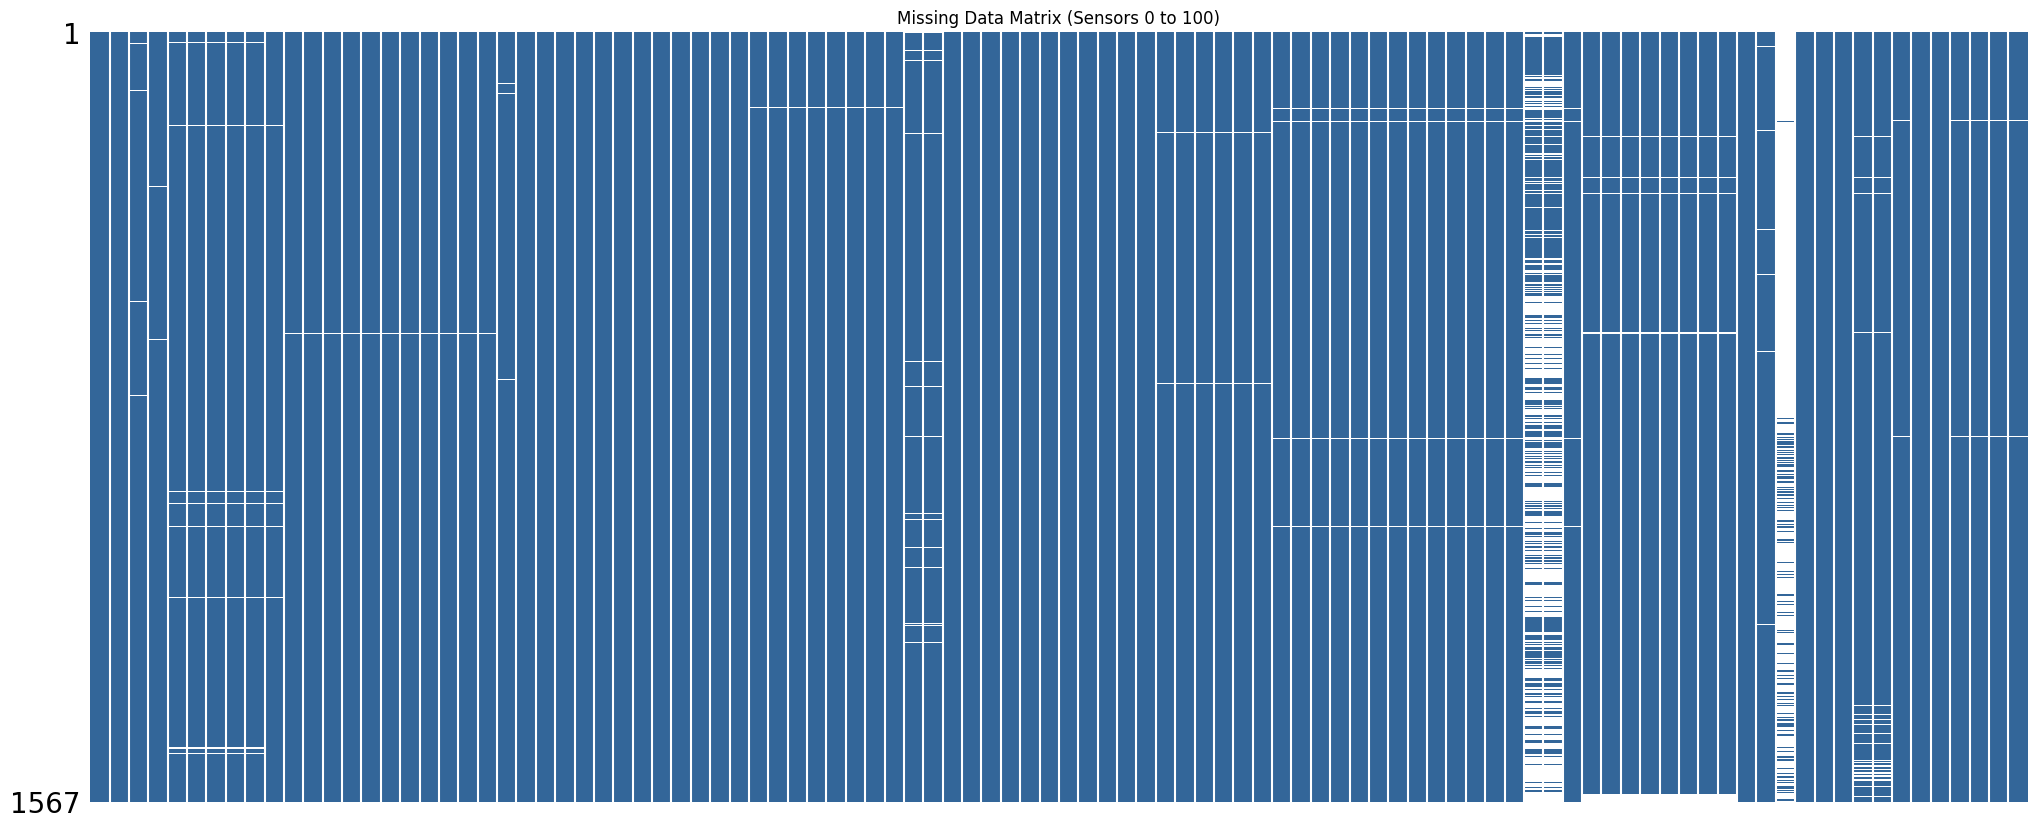

<Figure size 1200x600 with 0 Axes>

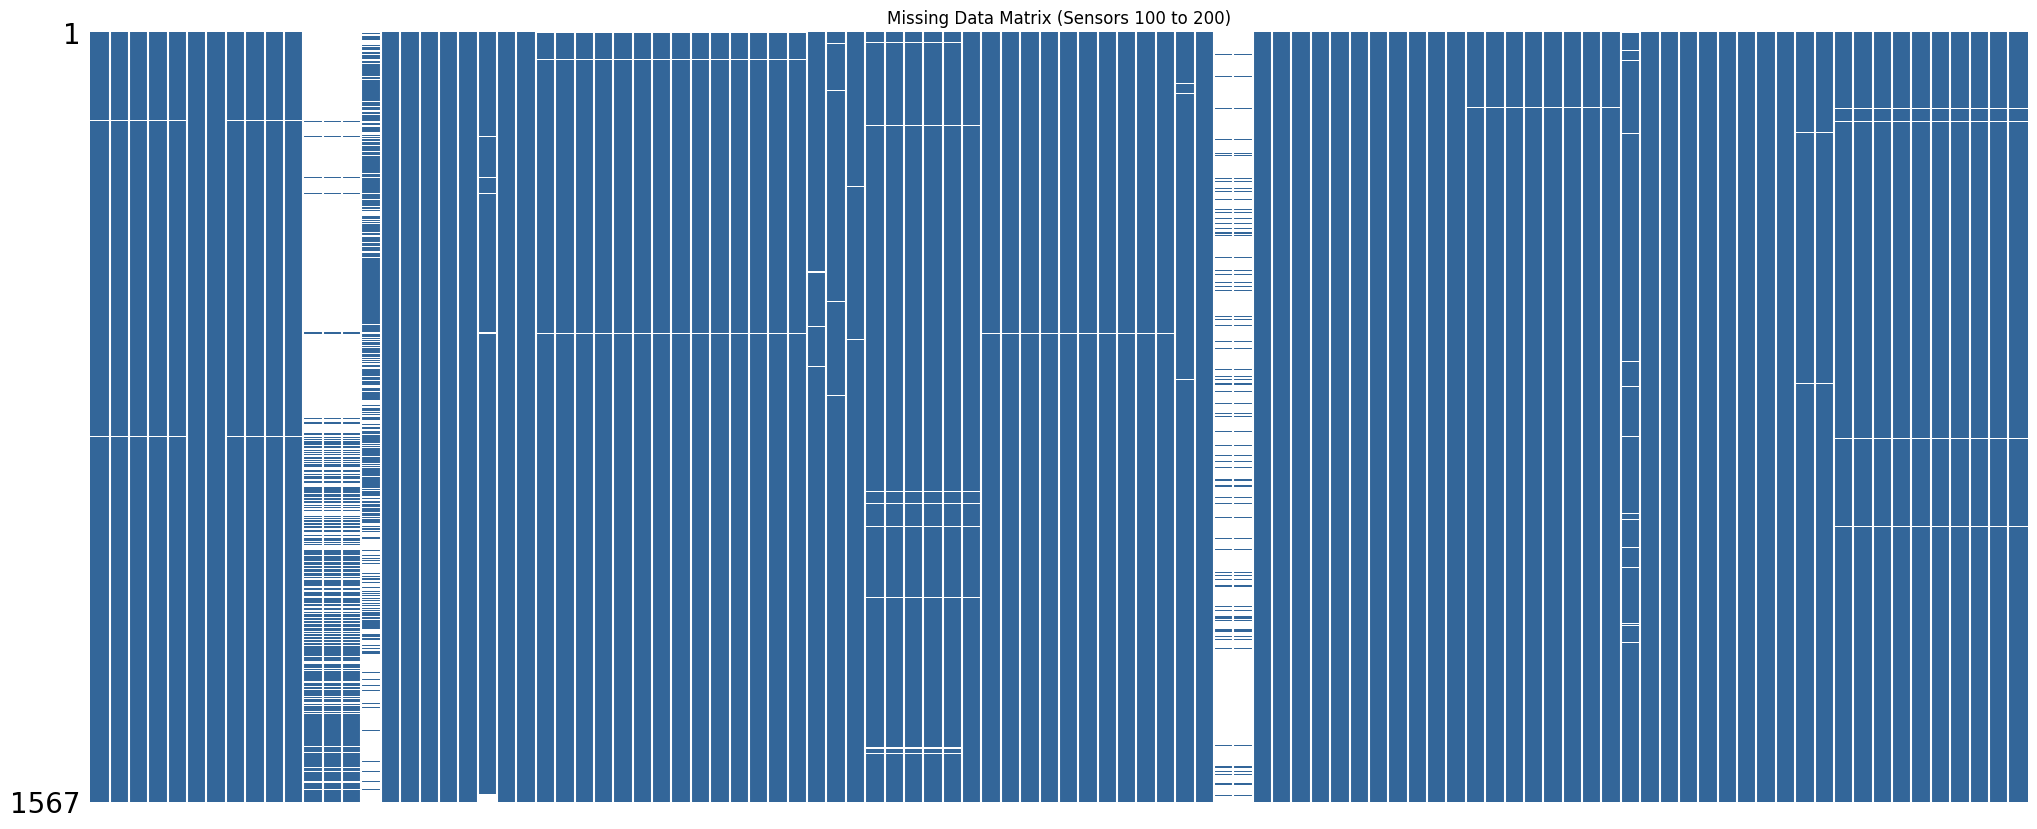

<Figure size 1200x600 with 0 Axes>

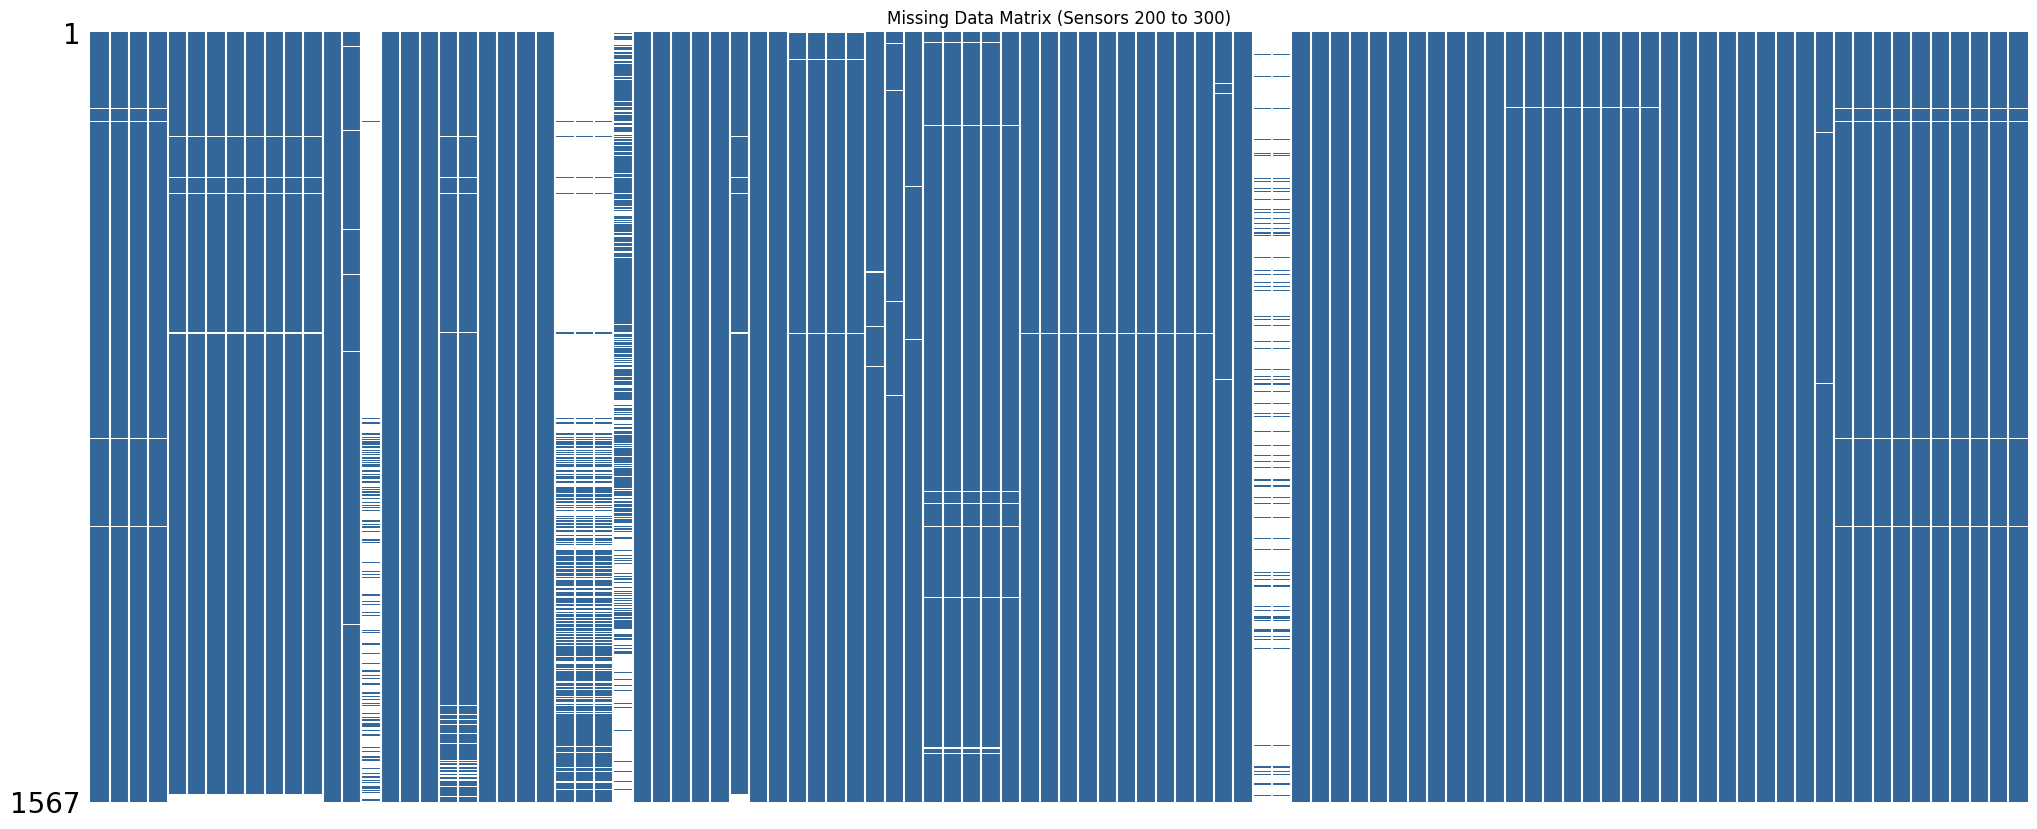

<Figure size 1200x600 with 0 Axes>

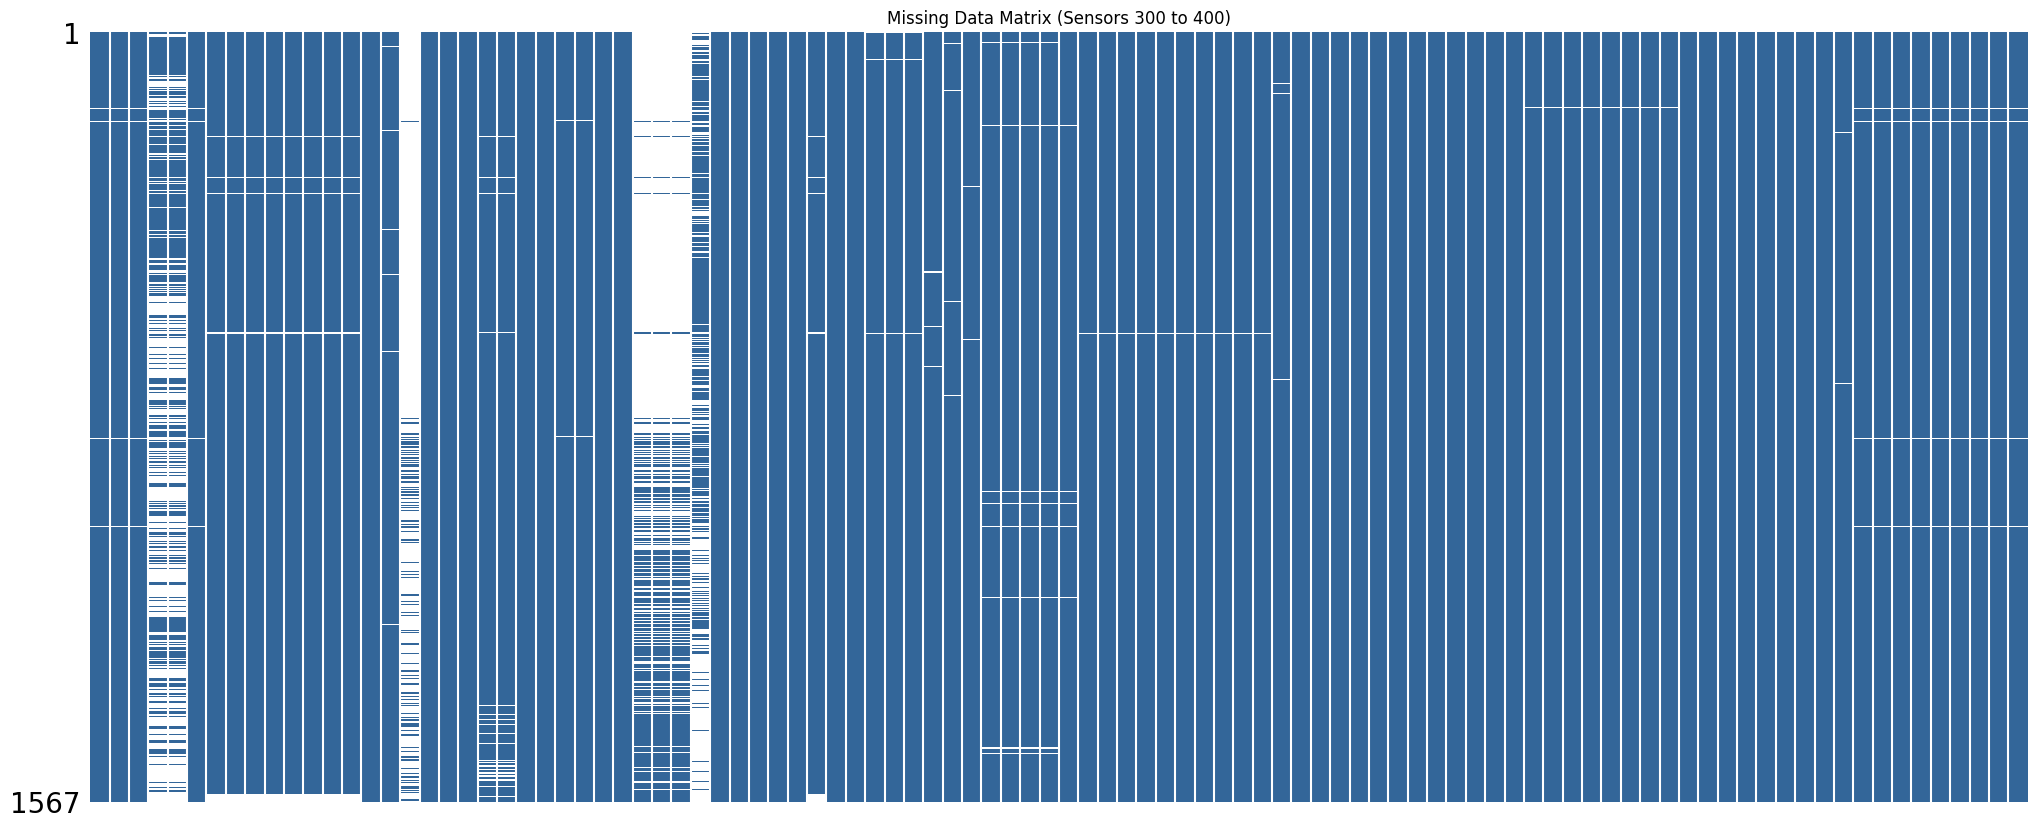

<Figure size 1200x600 with 0 Axes>

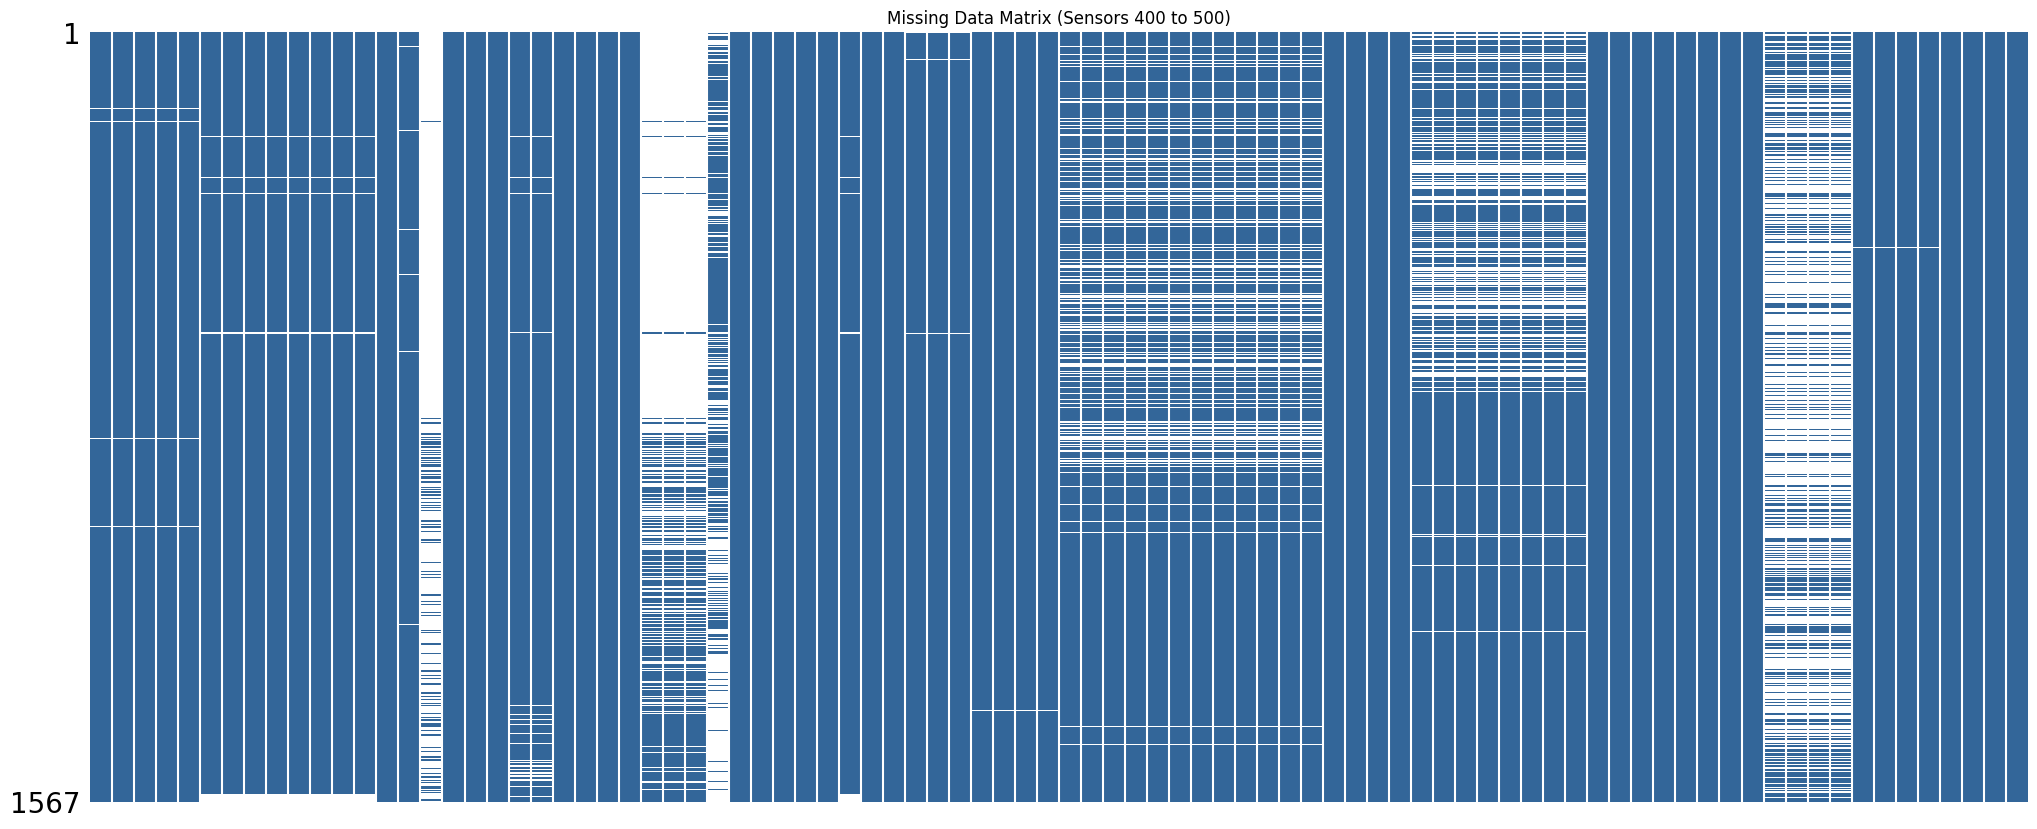

In [38]:
import matplotlib.pyplot as plt
import missingno as msno

# Plot 6 graphs of 100 sensors each
for i in range(5):
    start_col = i * 100
    end_col = start_col + 100

    plt.figure(figsize=(12, 6))

    msno.matrix(
        df.iloc[:, start_col:end_col],
        sparkline=False,
        color=(0.2, 0.4, 0.6)
    )

    plt.title(f"Missing Data Matrix (Sensors {start_col} to {end_col})")
    plt.show()

In [44]:
from collections import defaultdict
duplicates = {}

for i in range(df.shape[1]):
    col1 = df.columns[i]

    for j in range(i + 1, df.shape[1]):
        col2 = df.columns[j]

        if df[col1].equals(df[col2]):
            duplicates[col1] = col2

groups = defaultdict(list)

for k, v in duplicates.items():
    groups[v].append(k)

for representative, dupes in groups.items():
    print(f"\nRepresentative: {representative}")
    print("Duplicates:", dupes)


Representative: c_422
Duplicates: ['c_13', 'c_149', 'c_284']

Representative: c_461
Duplicates: ['c_52', 'c_179', 'c_186', 'c_189', 'c_315', 'c_322', 'c_325', 'c_451', 'c_458']

Representative: c_515
Duplicates: ['c_97', 'c_226', 'c_229', 'c_230', 'c_231', 'c_232', 'c_233', 'c_234', 'c_235', 'c_236', 'c_237', 'c_240', 'c_241', 'c_242', 'c_243', 'c_364', 'c_369', 'c_370', 'c_371', 'c_372', 'c_373', 'c_374', 'c_375', 'c_378', 'c_379', 'c_380', 'c_381', 'c_498', 'c_501', 'c_502', 'c_503', 'c_504', 'c_505', 'c_506', 'c_507', 'c_508', 'c_509', 'c_512', 'c_513', 'c_514']

Representative: c_414
Duplicates: ['c_141', 'c_276']

Representative: c_450
Duplicates: ['c_178', 'c_313', 'c_314', 'c_449']

Representative: c_466
Duplicates: ['c_190', 'c_191', 'c_192', 'c_193', 'c_194', 'c_326', 'c_327', 'c_328', 'c_329', 'c_330', 'c_462', 'c_463', 'c_464', 'c_465']

Representative: c_538
Duplicates: ['c_256', 'c_257', 'c_258', 'c_259', 'c_260', 'c_261', 'c_262', 'c_263', 'c_264', 'c_265', 'c_266', 'c_3

In [7]:
(
df.isnull()
.mean()
.loc[lambda x: x != 0]
.sort_values(ascending=False)
.head(30)
)

c_292    0.911934
c_157    0.911934
c_158    0.911934
c_293    0.911934
c_492    0.855775
c_220    0.855775
c_358    0.855775
c_85     0.855775
c_516    0.649649
c_517    0.649649
c_382    0.649649
c_111    0.649649
c_383    0.649649
c_384    0.649649
c_246    0.649649
c_244    0.649649
c_245    0.649649
c_110    0.649649
c_518    0.649649
c_109    0.649649
c_579    0.605616
c_581    0.605616
c_578    0.605616
c_580    0.605616
c_346    0.506701
c_72     0.506701
c_73     0.506701
c_345    0.506701
c_247    0.456286
c_385    0.456286
dtype: float64

,missing_rate,n_observed,n_unique_observed,var_observed_only,std_observed_only,median_observed,var_after_median_impute,pct_equal_to_median_after_impute
sensor,,,,,,,,
c_292,0.911934,138,92,0.000132,0.011494,0.01100,0.000013,0.913210
c_157,0.911934,138,128,0.001563,0.039538,0.03545,0.000148,0.911934
c_158,0.911934,138,138,165525.954457,406.848810,1020.30005,14510.969986,0.911934
c_293,0.911934,138,138,18959.219883,137.692483,317.86710,1683.760335,0.911934
c_492,0.855775,226,226,3.095004,1.759262,8.00895,0.447925,0.855775
c_220,0.855775,226,69,0.000004,0.001989,0.00895,0.000001,0.855775
c_358,0.855775,226,20,0.000000,0.000395,0.00240,0.000000,0.874920
c_85,0.855775,226,97,0.000009,0.002928,0.11355,0.000001,0.855775
c_516,0.649649,549,498,116.292067,10.783880,0.17470,40.752695,0.650287



Missingness correlation (1 = always missing together):


,c_292,c_157,c_158,c_293,c_492,c_220,c_358,c_85,c_516,c_517
c_292,1.000,1.000,1.000,1.000,-0.096,-0.096,-0.096,-0.096,-0.110,-0.110
c_157,1.000,1.000,1.000,1.000,-0.096,-0.096,-0.096,-0.096,-0.110,-0.110
c_158,1.000,1.000,1.000,1.000,-0.096,-0.096,-0.096,-0.096,-0.110,-0.110
c_293,1.000,1.000,1.000,1.000,-0.096,-0.096,-0.096,-0.096,-0.110,-0.110
c_492,-0.096,-0.096,-0.096,-0.096,1.000,1.000,1.000,1.000,0.521,0.521
c_220,-0.096,-0.096,-0.096,-0.096,1.000,1.000,1.000,1.000,0.521,0.521
c_358,-0.096,-0.096,-0.096,-0.096,1.000,1.000,1.000,1.000,0.521,0.521
c_85,-0.096,-0.096,-0.096,-0.096,1.000,1.000,1.000,1.000,0.521,0.521
c_516,-0.110,-0.110,-0.110,-0.110,0.521,0.521,0.521,0.521,1.000,1.000
c_517,-0.110,-0.110,-0.110,-0.110,0.521,0.521,0.521,0.521,1.000,1.000



Fraction of rows where ALL 10 sensors missing: 0.5712
Fraction of rows where AT LEAST ONE sensor observed: 0.4288

Value correlation (pairwise complete observations):


,c_292,c_157,c_158,c_293,c_492,c_220,c_358,c_85,c_516,c_517
c_292,1.000,0.994,-0.034,-0.013,NaN,NaN,NaN,NaN,0.261,-0.224
c_157,0.994,1.000,-0.046,-0.029,NaN,NaN,NaN,NaN,0.215,-0.207
c_158,-0.034,-0.046,1.000,0.962,NaN,NaN,NaN,NaN,0.052,0.107
c_293,-0.013,-0.029,0.962,1.000,NaN,NaN,NaN,NaN,0.095,0.050
c_492,NaN,NaN,NaN,NaN,1.000,0.992,0.863,-0.046,-0.033,0.103
c_220,NaN,NaN,NaN,NaN,0.992,1.000,0.872,0.074,-0.032,0.115
c_358,NaN,NaN,NaN,NaN,0.863,0.872,1.000,0.085,-0.020,0.061
c_85,NaN,NaN,NaN,NaN,-0.046,0.074,0.085,1.000,0.012,0.100
c_516,0.261,0.215,0.052,0.095,-0.033,-0.032,-0.020,0.012,1.000,0.976
c_517,-0.224,-0.207,0.107,0.050,0.103,0.115,0.061,0.100,0.976,1.000



Value correlation after per-column median impute:


,c_292,c_157,c_158,c_293,c_492,c_220,c_358,c_85,c_516,c_517
c_292,1.000,0.994,-0.020,0.022,-0.003,-0.003,-0.005,0.021,-0.002,-0.010
c_157,0.994,1.000,-0.032,0.006,-0.004,-0.004,-0.006,0.021,-0.002,-0.009
c_158,-0.020,-0.032,1.000,0.960,0.003,-0.003,0.003,-0.044,-0.000,0.004
c_293,0.022,0.006,0.960,1.000,0.001,-0.004,0.004,-0.043,-0.001,0.001
c_492,-0.003,-0.004,0.003,0.001,1.000,0.992,0.864,-0.065,-0.001,0.015
c_220,-0.003,-0.004,-0.003,-0.004,0.992,1.000,0.873,0.042,-0.001,0.016
c_358,-0.005,-0.006,0.003,0.004,0.864,0.873,1.000,0.058,-0.001,0.009
c_85,0.021,0.021,-0.044,-0.043,-0.065,0.042,0.058,1.000,0.002,0.014
c_516,-0.002,-0.002,-0.000,-0.001,-0.001,-0.001,-0.001,0.002,1.000,0.974
c_517,-0.010,-0.009,0.004,0.001,0.015,0.016,0.009,0.014,0.974,1.000


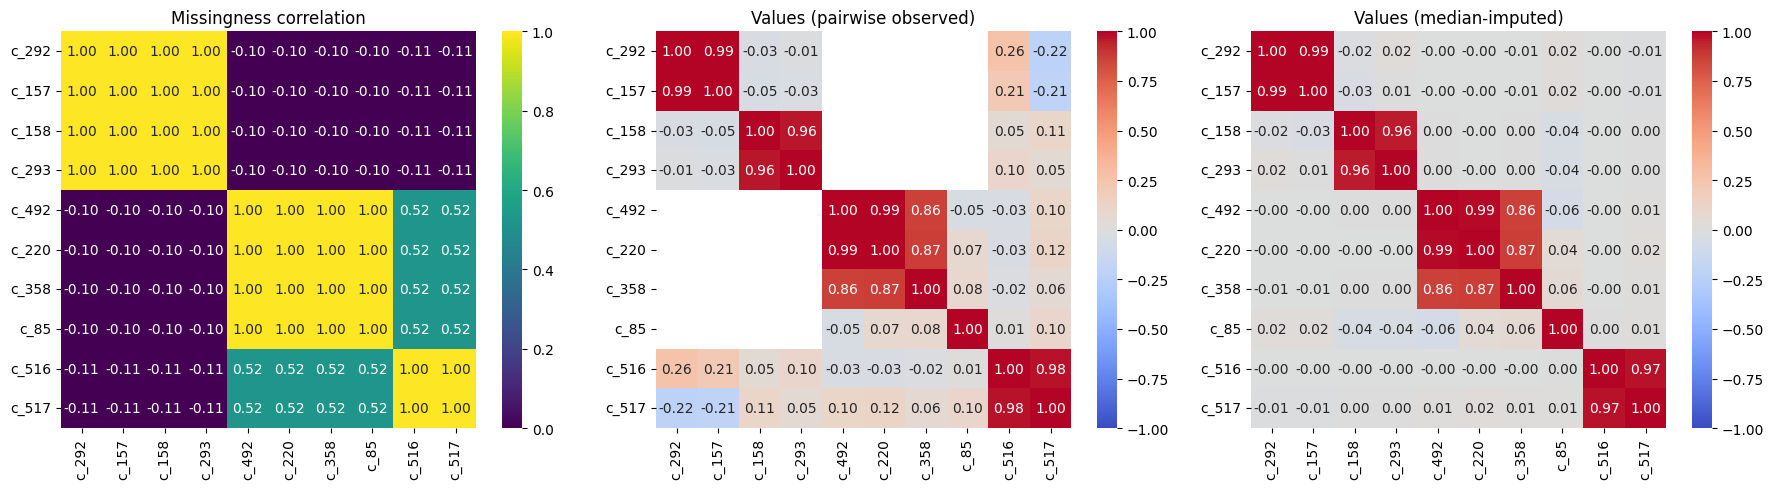


Pairwise checks when both sensors observed:


,a,b,n_both_observed,pearson_on_overlap,max_abs_diff,mean_abs_diff,pct_exact_equal
0,c_292,c_157,138,0.993880,0.2045,0.032617,0.0
30,c_492,c_220,226,0.992431,21.0203,8.161730,0.0
44,c_516,c_517,549,0.975506,139.5846,1.572714,0.0
17,c_158,c_293,138,0.962457,1626.0738,704.099581,0.0
14,c_157,c_85,5,0.936025,0.0856,0.072180,0.0
35,c_220,c_358,226,0.872021,0.0193,0.006770,0.0
31,c_492,c_358,226,0.862925,21.0396,8.168500,0.0
6,c_292,c_85,5,0.841288,0.1027,0.099540,0.0
26,c_293,c_358,5,0.585992,593.1199,361.322440,0.0
24,c_293,c_492,5,0.585601,584.9958,353.944040,0.0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If df is not already in memory:
# import duckdb
# con = duckdb.connect("secom.duckdb", read_only=True)
# df = con.execute("SELECT * FROM public.stg_secom").df()

SENSORS = [
    "c_292", "c_157", "c_158", "c_293",  # ~91.2% missing
    "c_492", "c_220", "c_358", "c_85",    # ~85.6% missing
    "c_516", "c_517",                     # ~65.0% missing
]

missing = df[SENSORS].isna()

# --- 1) Missingness + variance summary ---
rows = []
for col in SENSORS:
    s = df[col]
    obs = s.dropna()
    imputed = s.fillna(s.median())

    rows.append(
        {
            "sensor": col,
            "missing_rate": s.isna().mean(),
            "n_observed": int(obs.shape[0]),
            "n_unique_observed": int(obs.nunique()),
            "var_observed_only": float(obs.var(ddof=1)) if len(obs) > 1 else np.nan,
            "std_observed_only": float(obs.std(ddof=1)) if len(obs) > 1 else np.nan,
            "median_observed": float(obs.median()) if len(obs) else np.nan,
            "var_after_median_impute": float(imputed.var(ddof=1)),
            "pct_equal_to_median_after_impute": float((imputed == imputed.median()).mean()),
        }
    )

summary = pd.DataFrame(rows).set_index("sensor")
display(summary.round(6))

# --- 2) Do extreme-missing sensors miss on the same rows? ---
missing_corr = missing.astype(int).corr()
print("\nMissingness correlation (1 = always missing together):")
display(missing_corr.round(3))

# Rows where ALL listed sensors are missing vs any observed
all_missing = missing.all(axis=1).mean()
any_observed = (~missing.all(axis=1)).mean()
print(f"\nFraction of rows where ALL {len(SENSORS)} sensors missing: {all_missing:.4f}")
print(f"Fraction of rows where AT LEAST ONE sensor observed: {any_observed:.4f}")

# --- 3) Value correlation (only where pairwise non-null) ---
value_corr = df[SENSORS].corr(method="pearson", min_periods=10)
print("\nValue correlation (pairwise complete observations):")
display(value_corr.round(3))

# --- 4) Value correlation after median impute (what the model mostly sees) ---
imputed = df[SENSORS].apply(lambda s: s.fillna(s.median()))
value_corr_imputed = imputed.corr()
print("\nValue correlation after per-column median impute:")
display(value_corr_imputed.round(3))

# --- 5) Heatmaps ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(missing_corr, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Missingness correlation")

sns.heatmap(value_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Values (pairwise observed)")

sns.heatmap(value_corr_imputed, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Values (median-imputed)")

plt.tight_layout()
plt.show()

# --- 6) Pairwise: are observed values identical when both present? ---
print("\nPairwise checks when both sensors observed:")
pairs = []
for i, a in enumerate(SENSORS):
    for b in SENSORS[i + 1 :]:
        mask = df[a].notna() & df[b].notna()
        n_both = int(mask.sum())
        if n_both == 0:
            pairs.append({"a": a, "b": b, "n_both_observed": 0})
            continue
        diff = (df.loc[mask, a] - df.loc[mask, b]).abs()
        pairs.append(
            {
                "a": a,
                "b": b,
                "n_both_observed": n_both,
                "pearson_on_overlap": float(df.loc[mask, [a, b]].corr().iloc[0, 1]),
                "max_abs_diff": float(diff.max()),
                "mean_abs_diff": float(diff.mean()),
                "pct_exact_equal": float((df.loc[mask, a] == df.loc[mask, b]).mean()),
            }
        )

pairs_df = pd.DataFrame(pairs).sort_values(["pct_exact_equal", "pearson_on_overlap"], ascending=False)
display(pairs_df.round(6))

In [12]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class SECOMPreprocessor(BaseEstimator, TransformerMixin):
    """
    Interpretable preprocessing for SECOM-style sensor data.

    Steps:
    1. Keep numeric sensor columns only
    2. Remove exact duplicate sensor columns
    3. Remove zero-variance / constant columns
    4. Drop only extreme-missing columns when observed signal is weak
    5. Add missingness indicators
    6. Median-impute remaining numeric values

    Fit only on training data to avoid leakage.
    """

    def __init__(
        self,
        add_missing_indicators=True,
        extreme_missing_threshold=0.90,
        min_observed_unique=2,
    ):
        self.add_missing_indicators = add_missing_indicators
        self.extreme_missing_threshold = extreme_missing_threshold
        self.min_observed_unique = min_observed_unique

    def fit(self, X, y=None):
        X = X.copy()

        # Step 1: keep numeric sensor columns only.
        X = X.select_dtypes(include="number")
        self.numeric_columns_ = X.columns.tolist()

        # Step 2: remove exact duplicate columns.
        duplicate_mask = X.T.duplicated()
        self.duplicate_columns_ = X.columns[duplicate_mask].tolist()
        X = X.drop(columns=self.duplicate_columns_)

        # Step 3: remove zero-variance / constant columns.
        observed_unique_counts = X.nunique(dropna=True)
        self.constant_columns_ = observed_unique_counts[
            observed_unique_counts <= 1
        ].index.tolist()
        X = X.drop(columns=self.constant_columns_)

        # Step 4: drop only extreme-missing columns with weak observed signal.
        missing_rates = X.isna().mean()
        observed_unique_counts = X.nunique(dropna=True)

        extreme_missing = missing_rates > self.extreme_missing_threshold
        weak_observed_signal = observed_unique_counts < self.min_observed_unique

        self.extreme_weak_columns_ = X.columns[
            extreme_missing & weak_observed_signal
        ].tolist()
        X = X.drop(columns=self.extreme_weak_columns_)

        # Columns retained after feature filtering.
        self.feature_columns_ = X.columns.tolist()

        # Step 5: record which columns get missingness indicators.
        if self.add_missing_indicators:
            self.indicator_columns_ = X.columns[X.isna().any()].tolist()
        else:
            self.indicator_columns_ = []

        # Step 6: learn median imputation values from training data only.
        self.medians_ = X.median()

        return self

    def transform(self, X):
        X = X.copy()

        # Apply the same column selection learned during fit.
        X = X.reindex(columns=self.numeric_columns_)
        X = X.drop(columns=self.duplicate_columns_, errors="ignore")
        X = X.drop(columns=self.constant_columns_, errors="ignore")
        X = X.drop(columns=self.extreme_weak_columns_, errors="ignore")
        X = X.reindex(columns=self.feature_columns_)

        # Preserve missingness as explicit signal before imputation.
        if self.add_missing_indicators:
            indicators = X[self.indicator_columns_].isna().astype("int8")
            indicators = indicators.add_suffix("__missing")
        else:
            indicators = None

        # Median imputation keeps features interpretable and robust to outliers.
        X = X.fillna(self.medians_)

        if indicators is not None:
            X = pd.concat([X, indicators], axis=1)

        return X

In [ ]:
# Keep target separate to avoid leakage.
# Replace "target" with the actual SECOM label column name if present.
X = df.drop(columns=["target"])
y = df["target"]

preprocessor = SECOMPreprocessor(
    add_missing_indicators=True,
    extreme_missing_threshold=0.90,
    min_observed_unique=2,
)

X_clean = preprocessor.fit_transform(X)
X_clean.describe()


,c_0,c_1,c_2,c_3,c_4,c_6,c_7,c_8,c_9,c_10,...,c_580__missing,c_581__missing,c_582__missing,c_583__missing,c_584__missing,c_585__missing,c_586__missing,c_587__missing,c_588__missing,c_589__missing
count,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,...,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000
mean,3014.441551,2495.866110,2200.551958,1395.383474,4.171281,101.116476,0.121825,1.462860,-0.000842,0.000146,...,0.605616,0.605616,0.000638,0.000638,0.000638,0.000638,0.000638,0.000638,0.000638,0.000638
std,73.480841,80.228143,29.380973,439.837330,56.103721,6.209385,0.008936,0.073849,0.015107,0.009296,...,0.488874,0.488874,0.025262,0.025262,0.025262,0.025262,0.025262,0.025262,0.025262,0.025262
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,82.131100,0.000000,1.191000,-0.053400,-0.034900,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2966.665000,2452.885000,2181.099950,1083.885800,1.017700,97.937800,0.121100,1.411250,-0.010800,-0.005600,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,101.512200,0.122400,1.461600,-0.001300,0.000400,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3056.540000,2538.745000,2218.055500,1590.169900,1.518800,104.530000,0.123800,1.516850,0.008400,0.005900,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,129.252200,0.128600,1.656400,0.074900,0.053000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
